In [8]:
# %% [code] Cell 1: Imports and Vectorized Math
import os
import time
import math
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import pybullet as p
import pybullet_data
import pybullet_utils.bullet_client as bullet_client
import matplotlib.pyplot as plt

# Stable Baselines 3 Components
from stable_baselines3 import SAC
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy

# --- OPTIMIZATION 1: Vectorized Math Helpers ---
# Replaces slow manual matrix calculations with PyBullet's C++ bindings

def get_quaternion_from_euler(euler_angles):
    """
    Fast conversion using PyBullet's internal C++ code.
    Input: [roll, pitch, yaw] (radians)
    Output: [x, y, z, w] (quaternion)
    """
    return p.getQuaternionFromEuler(euler_angles)

def get_angular_diff(q1, q2):
    """
    Calculates the angular difference between two quaternions using dot product.
    Much faster than manual matrix multiplication.
    """
    q1 = np.array(q1)
    q2 = np.array(q2)

    # Dot product gives the cosine of half the angle
    dot_prod = np.abs(np.dot(q1, q2))
    # Clamp to avoid numerical errors outside arccos domain
    dot_prod = np.clip(dot_prod, 0, 1)

    # Angle in radians
    return 2 * np.arccos(dot_prod)

print("Libraries loaded and math helpers defined.")

Libraries loaded and math helpers defined.


In [9]:
# %% [code] Cell: Deep Debug - URDF & Mesh Validator
import os
import xml.etree.ElementTree as ET

urdf_file = "RightArm.urdf"

# 1. Does the URDF itself exist?
if not os.path.exists(urdf_file):
    print(f"❌ CRITICAL: '{urdf_file}' is missing from files! Upload it.")
else:
    print(f"✅ Found '{urdf_file}'. Scanning for missing meshes...")

    # 2. Parse the URDF to find what meshes it needs
    try:
        tree = ET.parse(urdf_file)
        root = tree.getroot()

        missing_meshes = []
        found_meshes = []

        # Look for all <mesh filename="..."> tags
        for mesh in root.findall(".//mesh"):
            filename = mesh.get("filename")
            if filename:
                # Check if this file exists
                if not os.path.exists(filename):
                    missing_meshes.append(filename)
                else:
                    found_meshes.append(filename)

        # 3. Report Results
        if len(missing_meshes) > 0:
            print("\n🚨 CAUSE OF ERROR FOUND: The URDF is looking for these files, but cannot find them:")
            for m in missing_meshes:
                print(f"   - {m}")
            print("\n👉 FIX: Check if you uploaded these files. Also check for 'meshes/' prefixes or case sensitivity (Link00.stl vs link00.stl).")
        else:
            print(f"\n✅ All {len(found_meshes)} meshes found. File paths look correct.")
            print("If it still fails, the .STL files themselves might be corrupted or empty.")

    except Exception as e:
        print(f"❌ Error parsing URDF XML: {e}")

✅ Found 'RightArm.urdf'. Scanning for missing meshes...

✅ All 11 meshes found. File paths look correct.
If it still fails, the .STL files themselves might be corrupted or empty.


In [10]:
# %% [code] Cell: Robot Diagnostic Tool
import pybullet as p
import pybullet_data
import os

# Connect to GUI so we can see what's happening (or DIRECT for Colab)
p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setAdditionalSearchPath(os.getcwd())

print(f"📂 Looking for URDF in: {os.getcwd()}")

try:
    # Try loading the standard one
    robot_id = p.loadURDF("RightArm.urdf", [0, 0, 0], useFixedBase=True)
    print(f"✅ Robot loaded successfully! ID: {robot_id}")

    # COUNT JOINTS
    num_joints = p.getNumJoints(robot_id)
    print(f"🤖 Total Joints Found: {num_joints}")

    # PRINT JOINT INFO
    print("\n--- JOINT MAP ---")
    for i in range(num_joints):
        info = p.getJointInfo(robot_id, i)
        joint_name = info[1].decode("utf-8")
        joint_type = info[2] # 0=Revolute, 4=Fixed
        print(f"ID {i}: {joint_name} (Type: {joint_type})")

    # TEST GETTING STATE
    try:
        state = p.getJointState(robot_id, 0)
        print(f"\n✅ Test: Joint 0 state is {state}")
    except Exception as e:
        print(f"\n❌ Test Failed: Could not read Joint 0. Error: {e}")

except Exception as e:
    print(f"\n❌ CRITICAL FAILURE: {e}")
    print("Ensure 'RightArm.urdf' and all '.stl' files are in the Colab files tab.")

📂 Looking for URDF in: /Users/uchemudiuzoka/RobotTraining_Local1
✅ Robot loaded successfully! ID: 0
🤖 Total Joints Found: 10

--- JOINT MAP ---
ID 0: Joint 00-02 (Type: 1)
ID 1: Joint 02-03 (Type: 0)
ID 2: Joint 03-04 (Type: 0)
ID 3: Joint 04-05 (Type: 0)
ID 4: Joint 05-06 (Type: 0)
ID 5: Joint 06-07 (Type: 0)
ID 6: Joint 07-08 (Type: 0)
ID 7: Joint 08-09 (Type: 0)
ID 8: Joint 09-10 (Type: 0)
ID 9: Joint 10-11 (Type: 0)

✅ Test: Joint 0 state is (0.0, 0.0, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 0.0)


In [11]:
# %% [code] Cell 2: Final RightArmRobot Environment
class RightArmRobot(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "simulation_fps": 50}

    def __init__(self, render_mode="rgb_array"):
        super(RightArmRobot, self).__init__()
        self.render_mode = render_mode
        self.robot_id = None

        # CONFIRMED JOINT INDICES (From your diagnostic)
        # 0=Base, 1-9=Arm Links. Total 10.
        self.active_joints = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
        self.num_active_joints = len(self.active_joints)

        # Action Space: 10 joints
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(10,), dtype=np.float32)

        # Observation Space: 19 dimensions
        # [Dist(1), AngleDiff(1), TargetPos(3), CurrPos(3), CurrQuat(4), TargetQuat(4), Joint0, Joint1, Joint2(3)]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(19,), dtype=np.float32)

        # Tolerances for "Success"
        self.pos_tol = 0.05
        self.orient_tol = 100.0
        self.max_step_size = 200

        # Connect to PyBullet
        connection_mode = p.DIRECT if render_mode != "human" else p.GUI
        self._bullet_client = bullet_client.BulletClient(connection_mode=connection_mode)
        self._bullet_client.setAdditionalSearchPath(os.getcwd())
        self._bullet_client.setAdditionalSearchPath(pybullet_data.getDataPath())

        # Load the robot immediately
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_number = 0

        self._bullet_client.resetSimulation()
        self._bullet_client.setGravity(0, 0, -9.8)

        # Load URDF (Using fixed path logic if needed)
        try:
            self.robot_id = self._bullet_client.loadURDF("RightArm.urdf", [0, 0, 0], useFixedBase=True)
        except:
            self.robot_id = self._bullet_client.loadURDF("RightArm_Fixed.urdf", [0, 0, 0], useFixedBase=True)

        # Randomize Target Position (Workspace)
        self.pos_target = np.array([
            np.random.uniform(-0.05, 0.05), # Narrower X
            np.random.uniform(0.40, 0.55),  # Closer Y (sweet spot)
            np.random.uniform(0.20, 0.30)   # Narrower Z
        ], dtype=np.float32)

        # Randomize Target Orientation
        euler_target = np.random.uniform([-2.35, -0.78, -np.pi], [-0.78, 0.78, np.pi])
        self.quat_target = get_quaternion_from_euler(euler_target)

        return self._get_obs(), {}

    def step(self, action):
        self.step_number += 1

        # Scale Actions
        scaled_action = action * np.pi
        scaled_action[0] = action[0] / 4.0 # Base joint scaling
        scaled_action[2] = -scaled_action[1] # Constraint

        # Apply Control
        self._bullet_client.setJointMotorControlArray(
            self.robot_id,
            self.active_joints,
            p.POSITION_CONTROL,
            targetPositions=scaled_action
        )
        self._bullet_client.stepSimulation()

        # Get End Effector (Index 9 is the last joint you found)
        link_state = self._bullet_client.getLinkState(self.robot_id, 9)
        current_pos = np.array(link_state[0])
        current_quat = np.array(link_state[1])

        # Calculate Rewards
        euclid_dist = np.linalg.norm(current_pos - self.pos_target)
        quat_diff = get_angular_diff(current_quat, self.quat_target)

        # FASTER R1 FORMULA: Distance + Time Penalty
        reward = -euclid_dist - (quat_diff * 0.1) - 0.01

        terminated = (euclid_dist < self.pos_tol) and (quat_diff < self.orient_tol)
        if terminated: reward += 10.0

        truncated = self.step_number >= self.max_step_size

        obs = self._get_obs(dist=euclid_dist, q_diff=quat_diff, curr_pos=current_pos, curr_quat=current_quat)
        info = {"is_success": terminated, "dist_error": euclid_dist, "angle_error": quat_diff}

        return obs, reward, terminated, truncated, info

    def _get_obs(self, dist=0, q_diff=0, curr_pos=None, curr_quat=None):
        if curr_pos is None:
            link_state = self._bullet_client.getLinkState(self.robot_id, 9)
            curr_pos = np.array(link_state[0])
            curr_quat = np.array(link_state[1])
            dist = np.linalg.norm(curr_pos - self.pos_target)
            q_diff = get_angular_diff(curr_quat, self.quat_target)

        # Get States for First 3 Joints (Confirmed indices 0, 1, 2 exist)
        joint_states = [self._bullet_client.getJointState(self.robot_id, i)[0] for i in [0, 1, 2]]

        return np.concatenate([
            [dist], [q_diff],
            self.pos_target, curr_pos,
            curr_quat, self.quat_target,
            joint_states
        ]).astype(np.float32)

In [12]:
# %% [code] Cell 3: Visual Plotting Callback
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
from IPython.display import clear_output

class PlottingCallback(BaseCallback):
    """
    Custom Callback to plot 'Faster R1' metrics:
    1. Cumulative Reward (Is it learning?)
    2. Episode Length (Is it getting faster?)
    3. Final Distance Error (Is it accurate?)
    """
    def __init__(self, verbose=0):
        super(PlottingCallback, self).__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.final_dist_errors = []
        self.final_angle_errors = []
        self.success_rate = []
        self.recent_successes = []

    def _on_step(self) -> bool:
        # Check if any environment in the vector has finished an episode
        if "dones" in self.locals and self.locals["dones"][0]:
            info = self.locals["infos"][0]

            # 1. Extract Reward & Length (Provided by Monitor wrapper)
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])

            # 2. Extract Custom Metrics (From our RightArmRobot info dict)
            # We default to 0.0 if keys aren't found to prevent crashes
            dist_error = info.get("dist_error", 0.0)
            angle_error = info.get("angle_error", 0.0)
            is_success = info.get("is_success", False)

            self.final_dist_errors.append(dist_error)
            self.final_angle_errors.append(angle_error)

            # 3. Track Success Rate (Rolling average of last 50)
            self.recent_successes.append(1 if is_success else 0)
            if len(self.recent_successes) > 50: self.recent_successes.pop(0)
            self.success_rate.append(sum(self.recent_successes) / len(self.recent_successes))

        return True

    def _on_training_end(self) -> None:
        """
        Generates the 2x2 Dashboard at the end of training.
        """
        # Create a nice dark-mode compatible figure
        plt.figure(figsize=(16, 10))

        # Plot 1: Rewards (The Learning Curve)
        plt.subplot(2, 2, 1)
        plt.plot(self.episode_rewards, color='blue', alpha=0.6)
        plt.title("Cumulative Rewards (Higher is Better)")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True, alpha=0.3)

        # Plot 2: Speed (The "Faster R1" Proof)
        plt.subplot(2, 2, 2)
        plt.plot(self.episode_lengths, color='orange', alpha=0.6)
        plt.title("Episode Length (Lower is Faster)")
        plt.xlabel("Episode")
        plt.ylabel("Timesteps")
        plt.grid(True, alpha=0.3)

        # Plot 3: Accuracy (Distance Error)
        plt.subplot(2, 2, 3)
        plt.plot(self.final_dist_errors, color='red', alpha=0.6)
        plt.title("Final Distance Error (Goal: < 0.02m)")
        plt.xlabel("Episode")
        plt.ylabel("Error (meters)")
        plt.axhline(y=0.02, color='green', linestyle='--', label="Success Threshold")
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 4: Success Rate
        plt.subplot(2, 2, 4)
        plt.plot(self.success_rate, color='green', linewidth=2)
        plt.title("Success Rate (Moving Avg)")
        plt.xlabel("Episode")
        plt.ylabel("Rate (0.0 - 1.0)")
        plt.ylim(0, 1.1)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print("Plotting Callback defined.")

Plotting Callback defined.


In [13]:
# %% [code] Cell 3: Visual Plotting Callback
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

class PlottingCallback(BaseCallback):
    """
    Advanced Diagnostic Callback for Phase 3 Ultrasound Training.
    Tracks Rewards, Speed, Success Rate, and precise Kinematic Deltas.
    """
    def __init__(self, verbose=0):
        super(PlottingCallback, self).__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        
        # Kinematic Tracking
        self.final_dist_errors = []
        self.change_dist_errors = []
        self.final_angle_errors = []
        self.change_angle_errors = []
        
        self.success_rate = []
        self.recent_successes = []

        # State trackers for Delta calculations
        self.initial_dist = 0.0
        self.initial_angle = 0.0
        self.episode_timesteps = 0

    def _on_step(self) -> bool:
        info = self.locals["infos"][0]
        
        # Safely get current metrics
        dist = info.get("dist_error", 0.0)
        angle = info.get("angle_error", 0.0)

        # Record starting position at timestep 0
        if self.episode_timesteps == 0:
            self.initial_dist = dist
            self.initial_angle = angle

        self.episode_timesteps += 1

        # Check if episode has finished
        if "dones" in self.locals and self.locals["dones"][0]:
            
            # 1. Extract Reward & Length
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])

            # 2. Record Final & Delta Kinematics
            self.final_dist_errors.append(dist)
            self.change_dist_errors.append(dist - self.initial_dist)
            
            self.final_angle_errors.append(angle)
            self.change_angle_errors.append(angle - self.initial_angle)

            # 3. Track Success Rate (Rolling average of last 50)
            is_success = info.get("is_success", False)
            self.recent_successes.append(1 if is_success else 0)
            if len(self.recent_successes) > 50: self.recent_successes.pop(0)
            self.success_rate.append(sum(self.recent_successes) / len(self.recent_successes))

            # Reset for next episode
            self.episode_timesteps = 0

        return True

    def _on_training_end(self) -> None:
        """Generates the advanced diagnostic dashboard."""
        plt.figure(figsize=(18, 10))

        # Plot 1: Learning Curve
        plt.subplot(2, 3, 1)
        plt.plot(self.episode_rewards, color='blue', alpha=0.6)
        plt.title("Cumulative Rewards")
        plt.ylabel("Reward")
        plt.grid(True, alpha=0.3)

        # Plot 2: Speed (Episode Length)
        plt.subplot(2, 3, 2)
        plt.plot(self.episode_lengths, color='orange', alpha=0.6)
        plt.title("Episode Length (Timesteps)")
        plt.grid(True, alpha=0.3)

        # Plot 3: Success Rate
        plt.subplot(2, 3, 3)
        plt.plot(self.success_rate, color='green', linewidth=2)
        plt.title("Success Rate (Rolling 50)")
        plt.ylabel("Rate (0.0 - 1.0)")
        plt.ylim(0, 1.1)
        plt.grid(True, alpha=0.3)

        # Plot 4: Final Distance Error
        plt.subplot(2, 3, 4)
        plt.plot(self.final_dist_errors, color='red', alpha=0.6)
        plt.axhline(y=0.05, color='black', linestyle='--', label="Target < 0.05m")
        plt.title("Final Euclid Distance")
        plt.ylabel("Meters")
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 5: Change in Distance
        plt.subplot(2, 3, 5)
        plt.plot(self.change_dist_errors, color='purple', alpha=0.6)
        plt.title("Change in Euclid Distance")
        plt.ylabel("Delta (Meters)")
        plt.grid(True, alpha=0.3)

        # Plot 6: Final Quat Difference
        plt.subplot(2, 3, 6)
        plt.plot(self.final_angle_errors, color='brown', alpha=0.6)
        plt.title("Final Quaternion Difference")
        plt.ylabel("Radians")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print("✅ Advanced Plotting Callback defined.")

✅ Advanced Plotting Callback defined.


argv[0]=
🚀 Starting 'Faster R1' Training...
Watch the 'Episode Length' graph. It should drop as the robot gets faster!


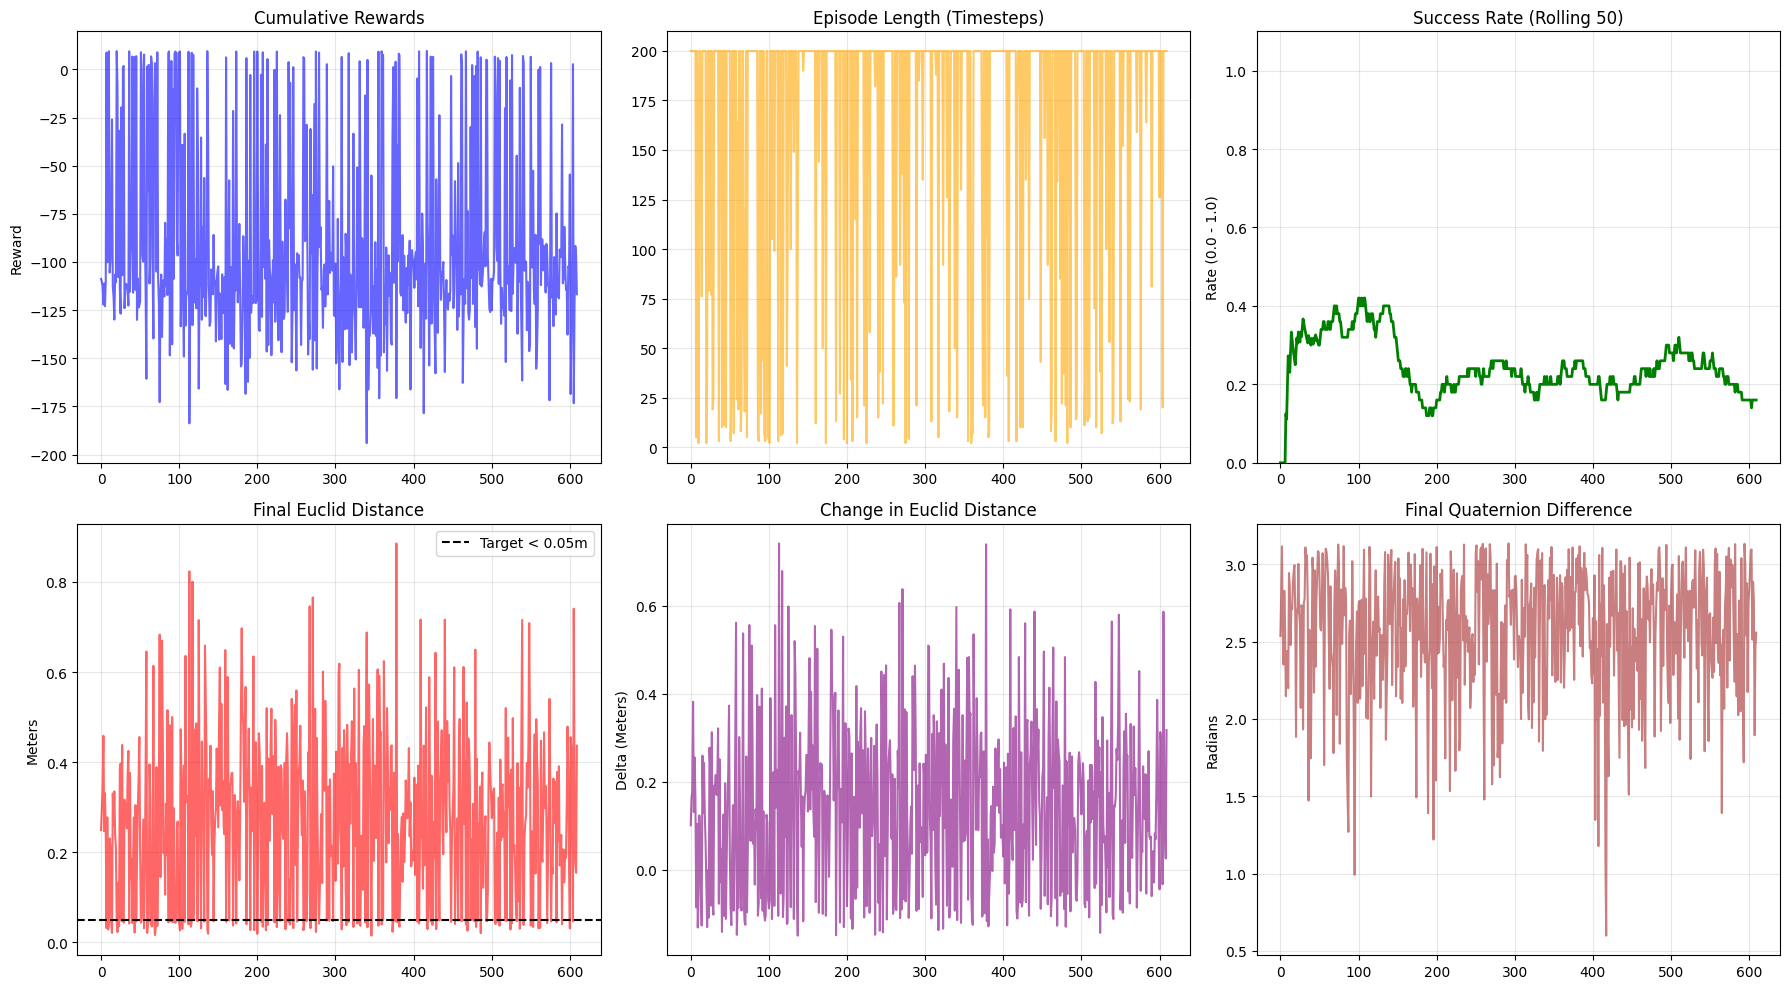

✅ Training Complete.


In [14]:
# %% [code] Cell 4: Train and Visualize
import os

# 1. Setup
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)
plotting_callback = PlottingCallback()

# 2. Init Env (With Monitor for plotting)
env = Monitor(RightArmRobot(render_mode="rgb_array"), log_dir)
env = DummyVecEnv([lambda: env])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

# 3. Init Model (SAC)
model = SAC("MlpPolicy", env, verbose=0, learning_rate=3e-4, buffer_size=10000, batch_size=256)

print("🚀 Starting 'Faster R1' Training...")
print("Watch the 'Episode Length' graph. It should drop as the robot gets faster!")

# 4. Train
model.learn(total_timesteps=100000, callback=plotting_callback)

# 5. Save
model.save("Faster_R1_RightArm_Phase1")
print("✅ Training Complete.")

🚀 Resuming Training for another 50,000 steps...
Goal: Push Success Rate from ~25% to >60%


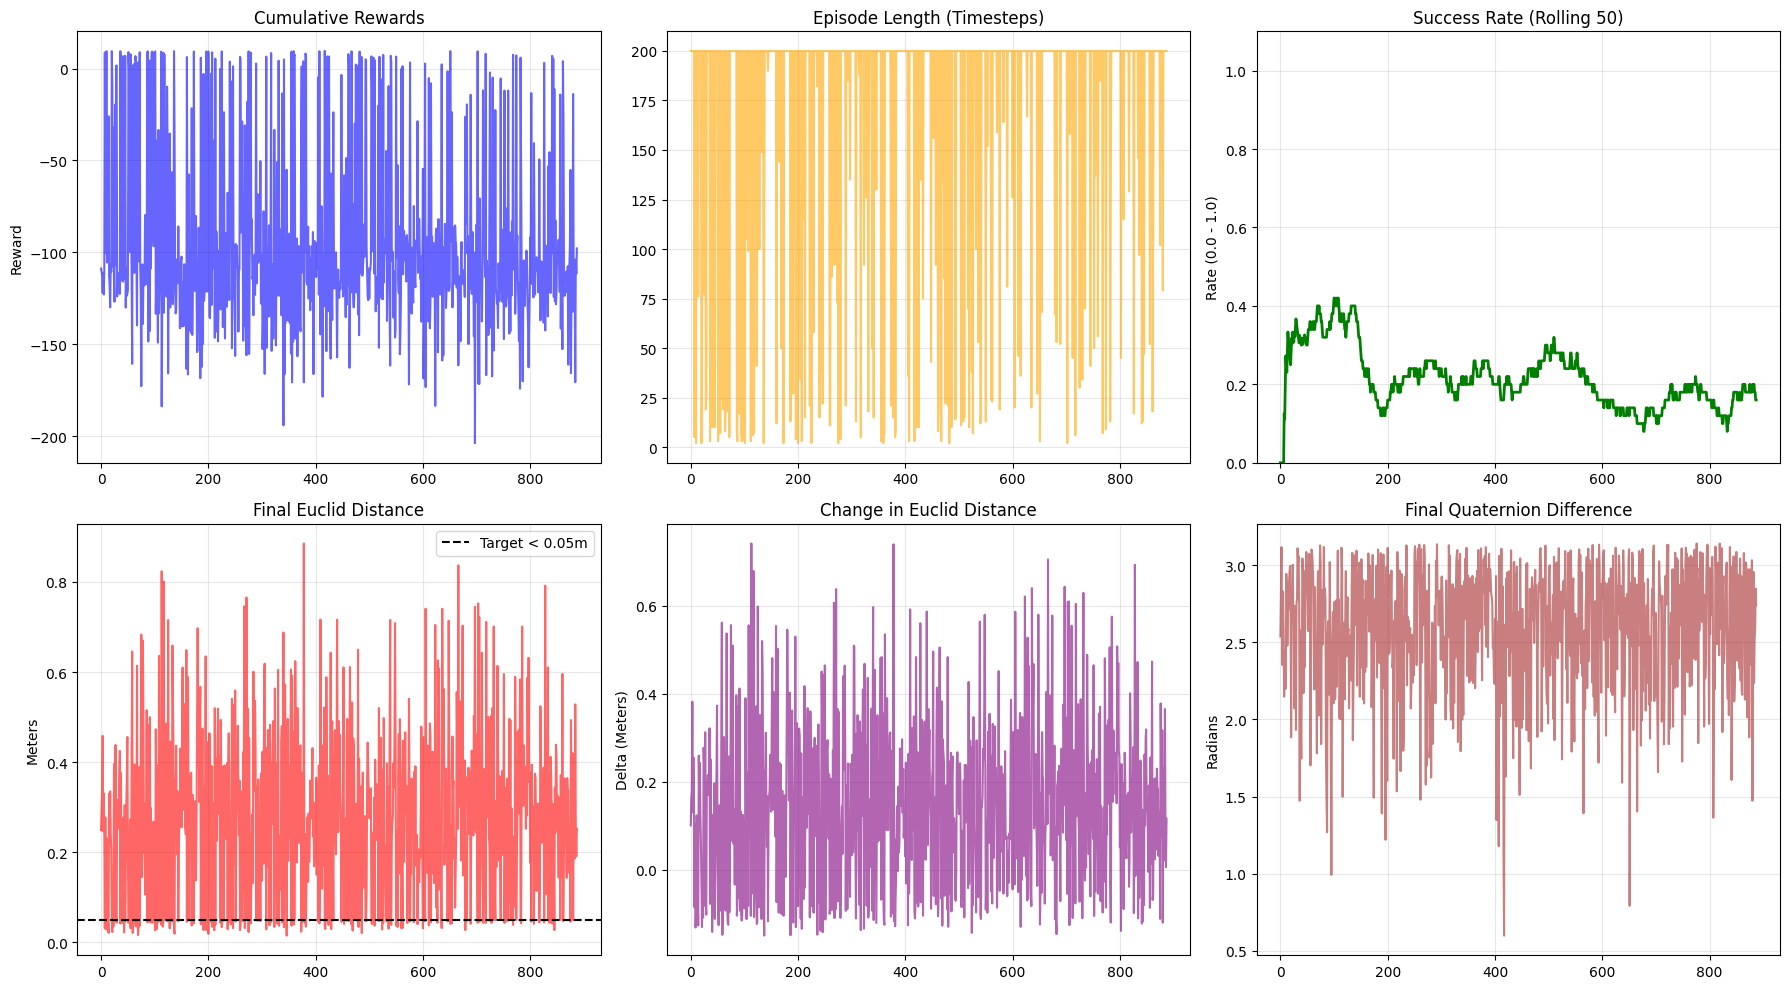

✅ Phase 2 Complete. Check the Success Rate graph!


In [15]:
# %% [code] Cell 5: Continue Training (Phase 2)

print("🚀 Resuming Training for another 50,000 steps...")
print("Goal: Push Success Rate from ~25% to >60%")

# 1. Continue learning on the EXISTING model object
# The reset_num_timesteps=False is crucial! It tells the logs to keep counting up from where you left off.
model.learn(total_timesteps=50000, callback=plotting_callback, reset_num_timesteps=False)

# 2. Save the "Smart" Model
model.save("Faster_R1_RightArm_Phase2")
env.save("vec_normalize_stats_phase2.pkl")

print("✅ Phase 2 Complete. Check the Success Rate graph!")

🚀 Starting Phase 3: High-Precision Tuning (100k steps)...
Goal: Push Success Rate > 70% and minimize Final Distance Error.


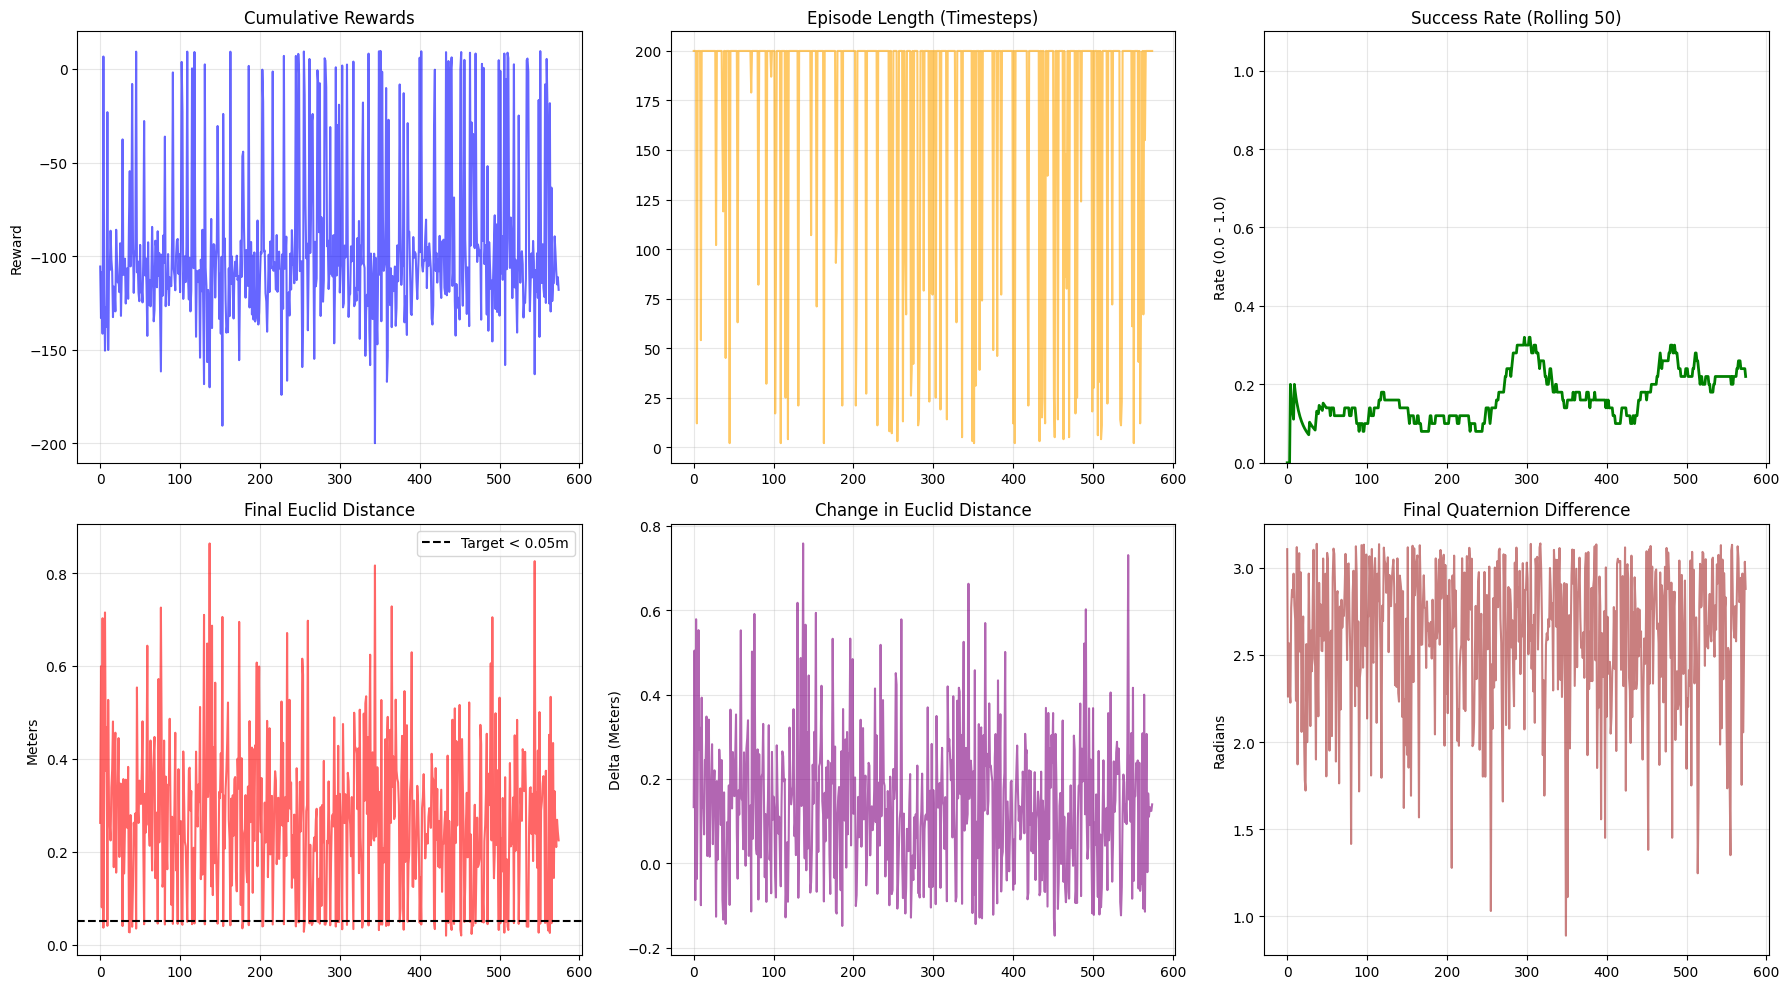

✅ Phase 3 Complete. The robot is now highly optimized!


In [16]:
# %% [code] Cell 5: Phase 3 Training (High Precision)
import os
from stable_baselines3 import SAC

print("🚀 Starting Phase 3: High-Precision Tuning (100k steps)...")
print("Goal: Push Success Rate > 70% and minimize Final Distance Error.")

# Initialize the new advanced callback
plotting_callback = PlottingCallback()

# 1. Load the Phase 2 Model
# We explicitly pass the current environment so the model knows where it is operating
model = SAC.load("Faster_R1_RightArm_Phase2", env=env)

# 2. Train for 100,000 steps
# reset_num_timesteps=False ensures TensorBoard/Logs don't overwrite previous phases
model.learn(total_timesteps=100000, callback=plotting_callback, reset_num_timesteps=False)

# 3. Save the "Phase 3" Expert Model
model.save("Faster_R1_RightArm_Phase3")
env.save("vec_normalize_stats_phase3.pkl")

print("✅ Phase 3 Complete. The robot is now highly optimized!")

In [ ]:
# %% [code] Cell 6: Visual Debugging (Watch the Robot)
import pybullet as p
import time
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

print("🔬 Launching Visual Diagnostic...")

# 1. Re-initialize the environment, but force GUI mode so we can watch
env_eval = RightArmRobot(render_mode="human")
env_eval = DummyVecEnv([lambda: env_eval])

# 2. Load the Normalization Stats (Crucial so it isn't blind)
try:
    env_eval = VecNormalize.load("vec_normalize_stats_phase3.pkl", env_eval)
    env_eval.training = False
    env_eval.norm_reward = False
except Exception as e:
    print(f"⚠️ Could not load stats: {e}")

# 3. Load the Phase 3 Brain
model = SAC.load("Faster_R1_RightArm_Phase3")

# 4. Watch 5 episodes
for episode in range(5):
    obs = env_eval.reset()
    done = False
    step_count = 0
    
    print(f"🎬 Starting Episode {episode + 1}...")
    while not done:
        # Predict the best action
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env_eval.step(action)
        step_count += 1
        
        # Slows it down
        time.sleep(0.02)
        
        # Stop after 200 time steps
        if step_count >= 200:
            print("   ❌ Timed out (200 steps).")
            break
            
        if info[0].get('is_success'):
            print(f"   ✅ Target reached in {step_count} steps!")
            break

# Close the window when done
p.disconnect()

🔬 Launching Visual Diagnostic...


error: Only one local in-process GUI/GUI_SERVER connection allowed. Use DIRECT connection mode or start a separate GUI physics server (ExampleBrowser, App_SharedMemoryPhysics_GUI, App_SharedMemoryPhysics_VR) and connect over SHARED_MEMORY, UDP or TCP instead.

: 